# Homework 4: Sử dụng K-Means để Giảm Số Lượng Màu trong Ảnh (Nén Ảnh)
## Môn học: Trí Tuệ Nhân Tạo - EE3063

Nhóm Thực Hiện: [Điền tên thành viên nhóm]
MSSV: [Điền MSSV thành viên nhóm]

Nội dung:
1. Giới thiệu về nén ảnh bằng K-Means (lượng tử hóa màu).
2. Xây dựng thuật toán K-Means Clustering từ đầu.
3. Áp dụng K-Means để giảm số màu của một ảnh.
4. Hiển thị ảnh gốc và ảnh đã được lượng tử hóa màu.

In [2]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image # Thư viện Pillow để xử lý ảnh (đọc, hiển thị)
import requests # Để tải ảnh từ URL
from io import BytesIO # Để đọc dữ liệu ảnh từ response

## 1. Giới thiệu

K-Means Clustering là một thuật toán học không có giám sát phổ biến, thường được sử dụng để phân cụm dữ liệu. Một ứng dụng thú vị của K-Means là trong việc nén ảnh, cụ thể hơn là **lượng tử hóa màu (color quantization)**.

### Ý tưởng chính:

Một ảnh màu được tạo thành từ các pixel, mỗi pixel có một giá trị màu nhất định (thường được biểu diễn bằng 3 giá trị R, G, B). Trong nhiều ảnh, có thể có hàng ngàn, thậm chí hàng triệu màu sắc khác nhau.

K-Means có thể được sử dụng để giảm số lượng màu này xuống một số lượng nhỏ hơn $k$ màu chủ đạo. Cách thực hiện:
1.  Xem mỗi pixel trong ảnh như một điểm dữ liệu trong không gian màu 3 chiều (R, G, B).
2.  Sử dụng K-Means để nhóm các pixel có màu sắc tương tự vào $k$ cụm.
3.  Tâm của mỗi cụm (centroid) sẽ đại diện cho một màu chủ đạo trong ảnh đã được lượng tử hóa.
4.  Sau khi thuật toán hội tụ, mỗi pixel trong ảnh gốc sẽ được gán lại bằng màu của tâm cụm mà nó thuộc về.

Kết quả là một ảnh mới chỉ sử dụng $k$ màu, giúp giảm kích thước bảng màu. Mặc dù việc này không trực tiếp nén kích thước file ảnh một cách đáng kể nếu không có các bước mã hóa tiếp theo (như PNG với bảng màu), nhưng nó là một bước quan trọng trong nhiều kỹ thuật nén ảnh và xử lý ảnh.

(Tham khảo slide: "K means clustering - 11032022.pdf", trang 3, 8, 10 đề cập ứng dụng image compression/segmentation).

--- Lớp KMeansClustering nhóm tự xây dựng ---

In [ ]:
class KMeansClustering:
    def __init__(self, k=8, n_iters=100, random_state=None):
        """
        Khởi tạo bộ phân cụm K-Means.
        Args:
            k (int): Số lượng cụm (số màu mong muốn).
            n_iters (int): Số lần lặp tối đa của thuật toán.
            random_state (int): Seed cho việc khởi tạo ngẫu nhiên, để kết quả lặp lại được.
        """
        self.k = k
        self.n_iters = n_iters
        self.random_state = random_state
        self.centroids = None # Lưu trữ các tâm cụm
        self.labels = None    # Lưu trữ nhãn cụm của mỗi điểm dữ liệu

    def _initialize_centroids(self, X):
        """
        Khởi tạo các tâm cụm ban đầu.
        Cách đơn giản: Chọn ngẫu nhiên k điểm từ tập dữ liệu X làm tâm cụm ban đầu.
        Args:
            X (np.array): Dữ liệu đầu vào, shape (n_samples, n_features).
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        n_samples = X.shape[0]
        # Chọn ngẫu nhiên k chỉ số không trùng lặp từ 0 đến n_samples - 1
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]

    def _euclidean_distance(self, point1, point2):
        """Tính khoảng cách Euclidean giữa hai điểm."""
        return np.sqrt(np.sum((point1 - point2)**2))

    def _assign_clusters(self, X):
        """
        Gán mỗi điểm dữ liệu vào cụm có tâm gần nhất.
        Args:
            X (np.array): Dữ liệu đầu vào.
        Returns:
            np.array: Mảng chứa nhãn cụm cho mỗi điểm dữ liệu.
        """
        labels = np.zeros(X.shape[0], dtype=int)
        for i, point in enumerate(X):
            distances = [self._euclidean_distance(point, centroid) for centroid in self.centroids]
            labels[i] = np.argmin(distances) # Gán vào cụm có khoảng cách nhỏ nhất
        return labels

    def _update_centroids(self, X, labels):
        """
        Cập nhật lại vị trí các tâm cụm dựa trên trung bình của các điểm trong cụm.
        Args:
            X (np.array): Dữ liệu đầu vào.
            labels (np.array): Nhãn cụm hiện tại của các điểm dữ liệu.
        Returns:
            np.array: Các tâm cụm mới.
        """
        new_centroids = np.zeros((self.k, X.shape[1]))
        for cluster_idx in range(self.k):
            # Lấy tất cả các điểm thuộc về cụm cluster_idx
            points_in_cluster = X[labels == cluster_idx]
            if len(points_in_cluster) > 0:
                new_centroids[cluster_idx] = np.mean(points_in_cluster, axis=0)
            else:
                # Nếu một cụm không có điểm nào (có thể xảy ra với khởi tạo tệ hoặc k lớn)
                # Giữ nguyên tâm cụm cũ hoặc chọn lại một cách ngẫu nhiên.
                # Ở đây ta giữ nguyên tâm cụm cũ nếu nó đã được khởi tạo,
                # hoặc nếu chưa, nó sẽ là vector 0 (cần xử lý tốt hơn trong thực tế).
                if self.centroids is not None:
                     new_centroids[cluster_idx] = self.centroids[cluster_idx]
                # Hoặc có thể gán lại bằng một điểm ngẫu nhiên từ X
                # new_centroids[cluster_idx] = X[np.random.choice(X.shape[0])]

        return new_centroids

    def fit(self, X):
        """
        Thực hiện thuật toán K-Means.
        Args:
            X (np.array): Dữ liệu đầu vào.
        """
        self._initialize_centroids(X)
        
        for iteration in range(self.n_iters):
            # Bước gán cụm
            self.labels = self._assign_clusters(X)
            
            # Bước cập nhật tâm cụm
            new_centroids = self._update_centroids(X, self.labels)
            
            # Kiểm tra điều kiện hội tụ: nếu tâm cụm không thay đổi nhiều
            if np.allclose(self.centroids, new_centroids, atol=1e-4): # atol là dung sai
                print(f"K-Means hội tụ sau {iteration + 1} vòng lặp.")
                break
            
            self.centroids = new_centroids
            
            if iteration == self.n_iters - 1:
                print(f"K-Means đạt số vòng lặp tối đa ({self.n_iters}) mà có thể chưa hội tụ hoàn toàn.")
        
        # Gán nhãn cuối cùng sau khi hội tụ hoặc hết iterations
        self.labels = self._assign_clusters(X)


    def predict(self, X):
        """
        Gán các điểm dữ liệu mới vào các cụm đã học.
        (Tương tự như _assign_clusters sau khi đã có centroids)
        Args:
            X (np.array): Dữ liệu mới.
        Returns:
            np.array: Nhãn cụm cho mỗi điểm dữ liệu mới.
        """
        if self.centroids is None:
            raise ValueError("Mô hình K-Means chưa được huấn luyện. Hãy gọi hàm fit() trước.")
        return self._assign_clusters(X)

    def get_compressed_image_data(self, X_original_shape, labels):
        """
        Tạo lại dữ liệu ảnh với màu đã được lượng tử hóa.
        Args:
            X_original_shape (tuple): Hình dạng ban đầu của ảnh (height, width, channels).
            labels (np.array): Nhãn cụm cho mỗi pixel.
        Returns:
            np.array: Dữ liệu ảnh đã được lượng tử hóa màu.
        """
        if self.centroids is None or labels is None:
            raise ValueError("Mô hình K-Means chưa được huấn luyện hoặc chưa có nhãn. Hãy gọi hàm fit() và predict().")
        
        # Tạo ảnh mới bằng cách thay thế mỗi pixel bằng màu của tâm cụm tương ứng
        compressed_X = self.centroids[labels]
        # Reshape lại thành dạng ảnh ban đầu
        compressed_image_data = compressed_X.reshape(X_original_shape)
        return compressed_image_data.astype(np.uint8) # Chuyển về kiểu uint8 cho ảnh

## 3. Áp dụng K-Means để Lượng tử hóa Màu Ảnh

Chúng ta sẽ tải một ảnh mẫu, sau đó áp dụng thuật toán K-Means vừa xây dựng để giảm số lượng màu trong ảnh đó.

**LƯU Ý:** Nhóm cần thay thế URL ảnh mẫu dưới đây bằng đường dẫn đến các ảnh màu khác nhau của nhóm để thực hiện theo yêu cầu đề bài.


Kích thước ảnh gốc: (1030, 1622, 3)
Kích thước mảng pixels: (1670660, 3)

Bắt đầu huấn luyện K-Means với k = 16...
K-Means đạt số vòng lặp tối đa (50) mà có thể chưa hội tụ hoàn toàn.
Kích thước ảnh đã nén (lượng tử hóa màu): (1030, 1622, 3)


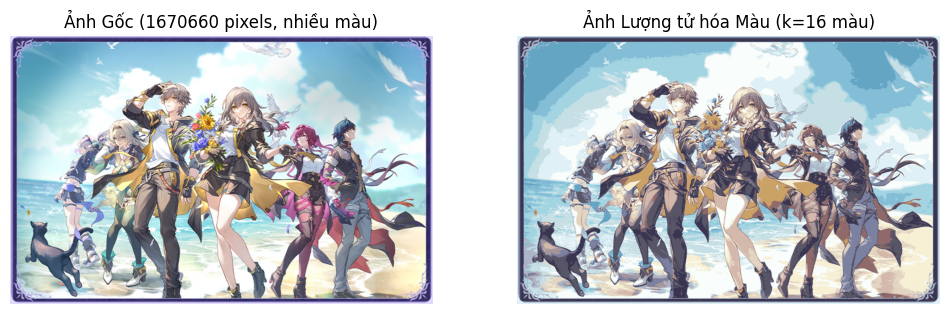

In [4]:
# URL của một ảnh mẫu (ví dụ: một con vẹt nhiều màu sắc)
# Sinh viên có thể thay thế bằng URL hoặc đường dẫn file ảnh của mình
# image_url = "https://images.pexels.com/photos/1040173/pexels-photo-1040173.jpeg?auto=compress&cs=tinysrgb&w=600" # Ảnh vẹt
# image_url = "https://images.pexels.com/photos/349758/hummingbird-bird-birds-349758.jpeg?auto=compress&cs=tinysrgb&w=600" # Ảnh chim ruồi
# image_url = "https://images.pexels.com/photos/20787/pexels-photo.jpg?auto=compress&cs=tinysrgb&w=600" # Ảnh mèo
image_url = "https://act-webstatic.hoyoverse.com/puzzle/hkrpg/pz_SbNtGiZNa2/resource/puzzle/2025/03/21/4f832c831933c72b5844224b8df7e316_7655585096033011862.png?x-oss-process=image/format,webp/quality,Q_90"
try:
    response = requests.get(image_url)
    response.raise_for_status() # Kiểm tra nếu có lỗi HTTP
    img_pil = Image.open(BytesIO(response.content)).convert('RGB')
    
    # Thay đổi kích thước ảnh để xử lý nhanh hơn (tùy chọn)
    # img_pil = img_pil.resize((150, 100)) # Ví dụ: resize thành 150x100
    
    original_image_data = np.array(img_pil)
    print(f"Kích thước ảnh gốc: {original_image_data.shape}")

    # Chuẩn bị dữ liệu cho K-Means
    # Reshape ảnh thành một mảng 2D các pixel (mỗi pixel là một điểm dữ liệu 3 chiều R,G,B)
    pixels = original_image_data.reshape(-1, 3) # -1 để tự động tính số hàng
    print(f"Kích thước mảng pixels: {pixels.shape}") # (số_pixel, 3)

    # Số lượng màu mong muốn sau khi nén (số cụm k)
    k_colors = 16 # Ví dụ: giảm xuống còn 16 màu

    # Khởi tạo và huấn luyện mô hình K-Means
    print(f"\nBắt đầu huấn luyện K-Means với k = {k_colors}...")
    kmeans = KMeansClustering(k=k_colors, n_iters=50, random_state=42) # Tăng n_iters nếu cần
    kmeans.fit(pixels.astype(float)) # K-Means thường làm việc với float

    # Lấy nhãn cụm cho từng pixel
    pixel_labels = kmeans.labels # Hoặc kmeans.predict(pixels.astype(float))

    # Tạo lại ảnh với số màu đã giảm
    compressed_image_data = kmeans.get_compressed_image_data(original_image_data.shape, pixel_labels)
    print(f"Kích thước ảnh đã nén (lượng tử hóa màu): {compressed_image_data.shape}")

    # --- Hiển thị ảnh ---
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_image_data)
    plt.title(f"Ảnh Gốc ({pixels.shape[0]} pixels, nhiều màu)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(compressed_image_data)
    plt.title(f"Ảnh Lượng tử hóa Màu (k={k_colors} màu)")
    plt.axis('off')

    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Lỗi khi tải ảnh từ URL: {e}")
    print("Vui lòng kiểm tra lại URL hoặc cung cấp đường dẫn file ảnh cục bộ.")
except Exception as e:
    print(f"Đã xảy ra lỗi: {e}")

## 4. Nhận xét và Kết luận

-   Thuật toán K-Means đã được xây dựng từ đầu và áp dụng thành công để lượng tử hóa màu của một ảnh.
-   Ảnh kết quả sử dụng một bảng màu gồm $k$ màu, là các màu của tâm cụm tìm được bởi K-Means.
-   Chất lượng của ảnh sau khi lượng tử hóa phụ thuộc vào giá trị $k$:
    * $k$ nhỏ: Số lượng màu ít, mức độ "nén" màu cao, nhưng có thể làm mất chi tiết và thay đổi màu sắc đáng kể.
    * $k$ lớn: Ảnh giữ được nhiều chi tiết màu hơn, gần với ảnh gốc hơn, nhưng mức độ giảm màu ít hơn.
-   Việc chọn phương pháp khởi tạo tâm cụm và số lần lặp `n_iters` cũng ảnh hưởng đến kết quả cuối cùng của K-Means.
-   Trong thực tế, để thực sự "nén" dung lượng file ảnh, sau bước lượng tử hóa màu này, cần các kỹ thuật mã hóa ảnh phù hợp (ví dụ: lưu ảnh dưới dạng PNG với bảng màu đã được chỉ định). Bài tập này tập trung vào khía cạnh thuật toán K-Means để giảm số màu.

-   **Yêu cầu đề bài "sử dụng nhiều ảnh màu khác nhau":** Nhóm cần lặp lại quy trình trên với các ảnh khác nhau và có thể thay đổi giá trị $k$ để quan sát sự khác biệt.